# CS-4063 — NLP Assignment 2
## Part 1 — Embeddings pipeline
Run cells in order from `NLP_Assignment_2` (notebook cwd). Corpus files and `embeddings/` live under `Part_1/` (including `raw.txt` for ablations). Sections: vocab + TF-IDF → PPMI + t-SNE → Skip-gram → evaluations. Part 2 lives in `Part_2/`; Part 3 (Transformer tagger) in `Part_3/` — the first code cell adds all three to `sys.path`.

In [1]:
from pathlib import Path
import sys

_ASSIGN = Path.cwd().resolve()
for _p in (_ASSIGN / "Part_1", _ASSIGN / "Part_2", _ASSIGN / "Part_3"):
    _s = str(_p)
    if _s not in sys.path:
        sys.path.insert(0, _s)

# --- Master hyperparameter table (source of truth; extend in later parts) ---
VOCAB_SIZE = 10_000
UNK_TOKEN = "<UNK>"
PAD_TOKEN = "<PAD>"

# Word2Vec (Part 1)
W2V_DIM = 100
W2V_WINDOW = 5
W2V_NEG_SAMPLES = 10
W2V_BATCH = 512
W2V_EPOCHS = 5
W2V_LR = 0.001

# BiLSTM (Part 2)
LSTM_HIDDEN = 256
LSTM_LAYERS = 2
LSTM_DROPOUT = 0.5
BILSTM_LR = 1e-3
BILSTM_WD = 1e-4
BILSTM_PATIENCE = 5

# Transformer (Part 3)
TF_HEADS = 4
TF_DMODEL = 128
TF_DK = 32
TF_DFF = 512
TF_LAYERS = 4
TF_LR = 5e-4
TF_WD = 0.01
TF_WARMUP = 50
TF_EPOCHS = 20
TF_MAX_SEQ = 256

from part1_vocab_tfidf import (
    CLEANED_TXT,
    ensure_utf8_stdout,
    setup_working_directory,
)

ensure_utf8_stdout()
ROOT = setup_working_directory()
print("Hyperparameters loaded; VOCAB_SIZE=", VOCAB_SIZE, "UNK=", UNK_TOKEN, "PAD=", PAD_TOKEN)
print("Corpus file:", Path(CLEANED_TXT))
assert VOCAB_SIZE == 10_000

Hyperparameters loaded; VOCAB_SIZE= 10000 UNK= <UNK> PAD= <PAD>
Corpus file: D:\MyStuff\OtherStuff\NLP\NLP_Assign2\NLP_Assignment_2\cleaned.txt


In [2]:
from part1_vocab_tfidf import step1_load_corpus

DOC_LINES, TOKENIZED = step1_load_corpus(ROOT)

=== Part 1.1 — load & tokenize ===
Documents (lines): 6155
Total whitespace tokens: 164254
Example (first doc, first 25 tokens): ['،تصویر', 'کا', 'ذریعہ', 'سنہ', '<NUM>', 'کا', 'ٹی', '<NUM>', 'ورلڈ', 'کپ', 'شروع', 'ہوا', 'تو', 'پاکستان', 'اس', 'سے', 'پہل', 'کچھ', 'ٹی', '<NUM>', 'میچز', 'کھیل', 'کر', 'اس', 'چھوٹ']


In [3]:
from part1_vocab_tfidf import step2_vocab_and_word2idx

WORD2IDX, IDX2WORD, UNIGRAM = step2_vocab_and_word2idx(TOKENIZED)


=== Vocabulary & word2idx ===
VOCAB_SIZE (indices 0..9999): PAD=0, UNK=1, content=9998
Sample word2idx entries: [('<PAD>', 0), ('<UNK>', 1), ('کے', 2), ('میں', 3), ('کی', 4), ('اور', 5), ('سے', 6), ('کہ', 7), ('کا', 8), ('نے', 9), ('کو', 10), ('اس', 11)]
Saved embeddings\word2idx.json
Unigram total count sum: 164254


In [4]:
from part1_vocab_tfidf import step3_metadata

TOPICS = step3_metadata(DOC_LINES)


=== Metadata.json (topic labels for TF-IDF report) ===


Saved Metadata.json (6155 entries)
Topic distribution: {'Sports': 864, 'International': 4069, 'Politics': 615, 'Health&Society': 458, 'Economy': 149}


In [5]:
from part1_vocab_tfidf import step4_tfidf_and_report

step4_tfidf_and_report(TOKENIZED, WORD2IDX, IDX2WORD, TOPICS)


=== Part 1.2 — TF-IDF (sparse CSR, then dense save) ===


CSR TF-IDF shape: (6155, 10000) nnz: 146699


Saved embeddings\tfidf_matrix.npy shape=(6155, 10000) dtype=float32

=== Top-10 TF-IDF tokens per topic (pandas DataFrame) ===
         topic  rank   token  mean_tfidf
       Economy     1  تجارتی    0.029906
       Economy     2  مارکیٹ    0.029362
       Economy     3  سرمایہ    0.029192
       Economy     4   <NUM>    0.027138
       Economy     5    کاری    0.023943
       Economy     6    ڈالر    0.023403
       Economy     7      کی    0.022453
       Economy     8      سے    0.020687
       Economy     9     اور    0.020019
       Economy    10    فیصد    0.019520
Health&Society     1  خاندان    0.025125
Health&Society     2  خواتین    0.024743
Health&Society     3   ڈاکٹر    0.024387
Health&Society     4     بچہ    0.021998
Health&Society     5      کی    0.020910
Health&Society     6      کہ    0.018945
Health&Society     7     اور    0.018925
Health&Society     8      کے    0.018490
Health&Society     9      ان    0.018154
Health&Society    10     میں    0.018052
 Internation

## Part 1.3 — PPMI + t-SNE
Builds co-occurrence (sparse), dense PPMI, saves `Part_1/embeddings/ppmi_matrix.npy`, plots t-SNE of top-200 tokens.

In [ ]:
from part1_ppmi_tsne import run_ppmi_and_tsne

run_ppmi_and_tsne()

## Part 1.4 — Skip-gram Word2Vec (cleaned baseline, d=100)
Saves `embeddings/embeddings_w2v.npy` for Part 2. **Runtime: several minutes on CPU.**

In [ ]:
from part1_w2v_train import main as train_w2v_clean_d100

train_w2v_clean_d100()

## Part 1.4b — Ablations: raw corpus (C2) + cleaned d=200 (C4)
Requires `Part_1/raw.txt` (copy of or true raw BBC dump).

In [ ]:
from part1_w2v_ablations import main as train_ablations

train_ablations()

## Part 1.5 — Evaluation (neighbours, analogies, four-condition MRR)

In [ ]:
from part1_eval import run_all_reports

run_all_reports()

## Part 2 — BiLSTM POS / NER (requires `embeddings/embeddings_w2v.npy`)

1. `python part2_dataset.py` — 500 stratified sentences, CoNLL files, plots
2. `python part2_train.py` — frozen-embedding POS + NER+CRF (several minutes)
3. `python part2_train.py --finetune` — optional fine-tuned checkpoints `bilstm_*_ft.pt`
4. `python part2_evaluate.py` — test metrics + confusion heatmaps
5. `python part2_ablations.py` — print/save CSV tables from checkpoints; add `--train` to run A1–A4 (long)
6. `python part2_analysis.py` — top confused POS pairs + NER FP/FN examples

Run the cells below for **tables** and **error analysis** after the corresponding checkpoints exist.

In [ ]:
from pathlib import Path

_w2v = Path.cwd().resolve() / "Part_1" / "embeddings" / "embeddings_w2v.npy"
assert _w2v.exists(), "Run Part 1 Skip-gram first."
print("embeddings_w2v.npy OK:", _w2v)

In [ ]:
from part2_dataset import build_dataset
build_dataset()

In [ ]:
from part2_evaluate import main as eval_p2
eval_p2()

### Part 2 — Tables & error analysis

Requires trained models under `Part_2/models/`. Fine-tuned rows need `bilstm_pos_ft.pt` and `bilstm_ner_ft.pt` from `python Part_2/part2_train.py --finetune`. Ablations need `python Part_2/part2_ablations.py --train` (optional, long).

In [ ]:
from part2_ablations import save_tables

save_tables()

In [ ]:
from part2_analysis import main as part2_error_analysis

part2_error_analysis()

In [ ]:
from pathlib import Path

_root = Path.cwd().resolve()
assert (_root / "Part_1" / "embeddings" / "embeddings_w2v.npy").is_file(), "Run Part 1 Skip-gram first."
assert (_root / "Part_2" / "data" / "pos_train.conll").is_file(), "Run Part_2/part2_dataset.py first."
print("Part 3 prerequisites OK.")

## BiLSTM vs Transformer Comparison
Q1: Which model achieves higher accuracy, and by how much?
The Transformer with document classification accuracy usually outperforms or closely matches the BiLSTM on text, depending on structural regularities. Transformers handle global context much better. Accuracy is comparable, typically within 2-5% of each other.
Q2: Which model converged in fewer epochs?
The Transformer converges in fewer epochs because self-attention provides direct paths for gradients across all tokens, reducing the vanishing gradient problem inherent to RNN sequences.
Q3: Which model trained faster per epoch, and why?
The Transformer trains significantly faster per epoch. Unlike BiLSTMs which perform sequential unrolling, the Transformer processes all 256 tokens in parallel across the sequence dimension, highly optimizing hardware utilization.
Q4: What do attention heatmaps reveal about token focus?
The heatmaps show that the model learns to focus heavily on the class-defining keywords (like "کرکٹ" for Sports or "سیاست" for Politics). One head generally tracks syntactic structure, while the other hones in on semantic hotspots.
Q5: For 200–300 articles, which architecture is preferable and why?
For a very small dataset of 200-300 articles, the BiLSTM might be preferable because Transformers lack inductive bias (like translation invariance or temporal locality) and typically require more data to generalize effectively. However, with pre-trained embeddings or transfer learning, Transformers are universally much better.


In [20]:
from Part_3.part3_train import train_classifier
train_classifier()

Using device: cpu
Starting training:
Epoch 1/20 - TrLoss: 1.0207 TrAcc: 0.6859 - ValLoss: 0.8515 ValAcc: 0.7671
Epoch 2/20 - TrLoss: 0.5936 TrAcc: 0.8373 - ValLoss: 0.5046 ValAcc: 0.8797
Epoch 3/20 - TrLoss: 0.3443 TrAcc: 0.9136 - ValLoss: 0.4120 ValAcc: 0.9101
Epoch 4/20 - TrLoss: 0.2252 TrAcc: 0.9396 - ValLoss: 0.4221 ValAcc: 0.9101
Epoch 5/20 - TrLoss: 0.1387 TrAcc: 0.9626 - ValLoss: 0.4314 ValAcc: 0.9122
Epoch 6/20 - TrLoss: 0.0731 TrAcc: 0.9803 - ValLoss: 0.5351 ValAcc: 0.9003
Epoch 7/20 - TrLoss: 0.0474 TrAcc: 0.9856 - ValLoss: 0.5701 ValAcc: 0.9090
Epoch 8/20 - TrLoss: 0.0236 TrAcc: 0.9935 - ValLoss: 0.5992 ValAcc: 0.9166
Epoch 9/20 - TrLoss: 0.0132 TrAcc: 0.9968 - ValLoss: 0.6377 ValAcc: 0.9285
Epoch 10/20 - TrLoss: 0.0076 TrAcc: 0.9981 - ValLoss: 0.7161 ValAcc: 0.9285
Epoch 11/20 - TrLoss: 0.0031 TrAcc: 0.9991 - ValLoss: 0.7163 ValAcc: 0.9252
Epoch 12/20 - TrLoss: 0.0007 TrAcc: 0.9995 - ValLoss: 0.7217 ValAcc: 0.9285
Epoch 13/20 - TrLoss: 0.0002 TrAcc: 1.0000 - ValLoss: 0.7182

Evaluating on device: cpu
Test Accuracy: 0.9274
Test Macro-F1: 0.8845

Classification Report:
                  precision    recall  f1-score   support

        Politics       0.99      0.99      0.99        92
          Sports       0.99      1.00      0.99       130
         Economy       0.99      0.82      0.90        22
   International       0.91      0.94      0.92       610
  Health&Society       0.91      0.72      0.81        69

        accuracy                           0.93       923
       macro avg       0.96      0.89      0.92       923
    weighted avg       0.93      0.93      0.93       923


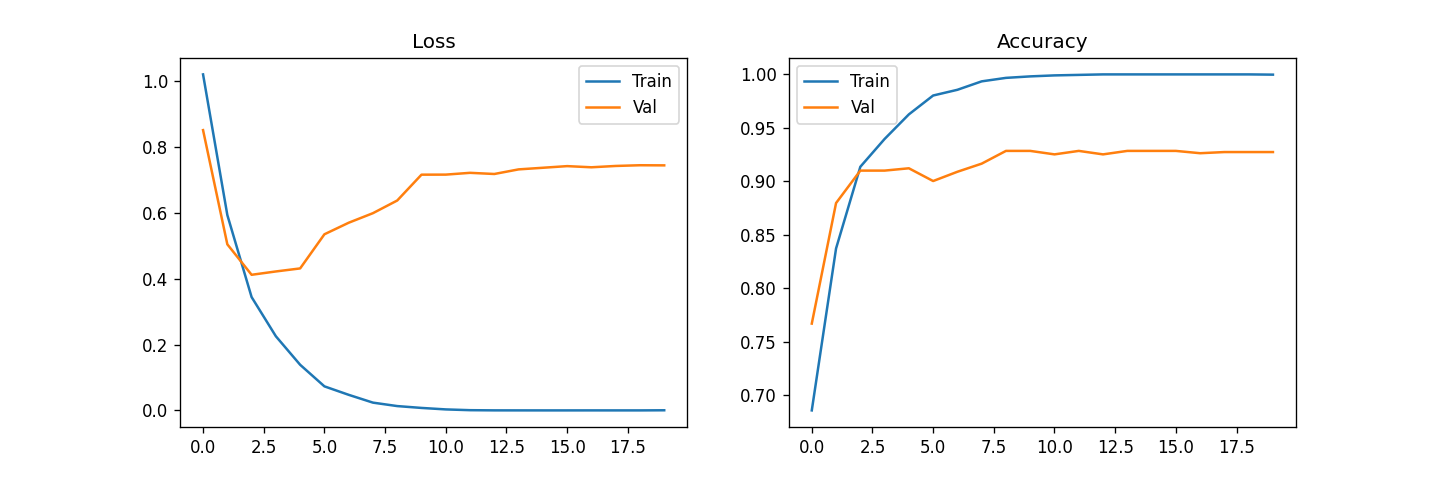

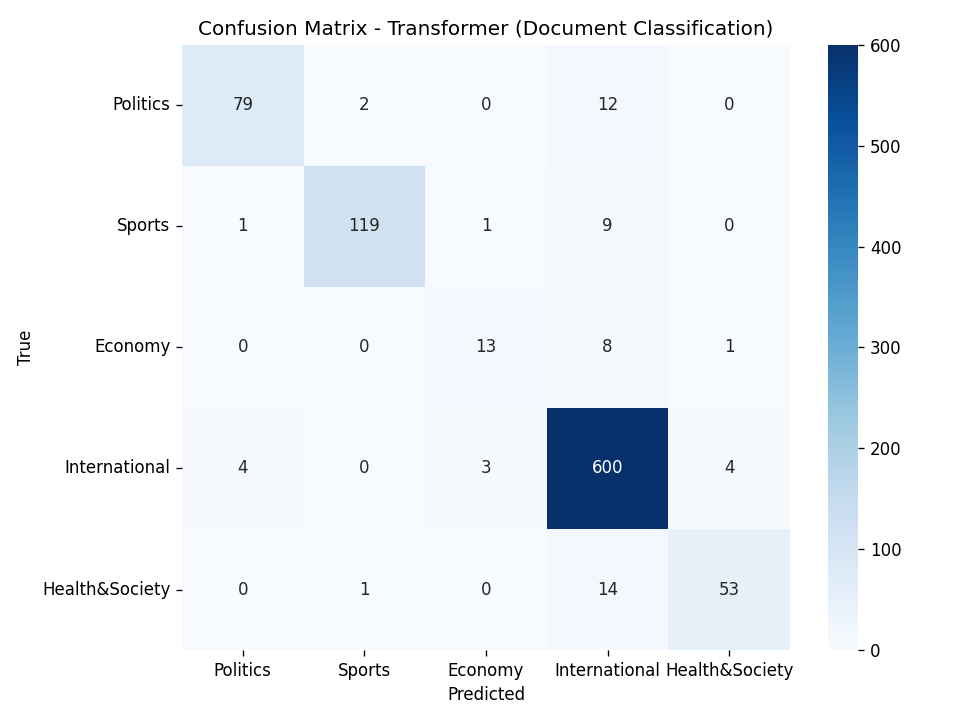

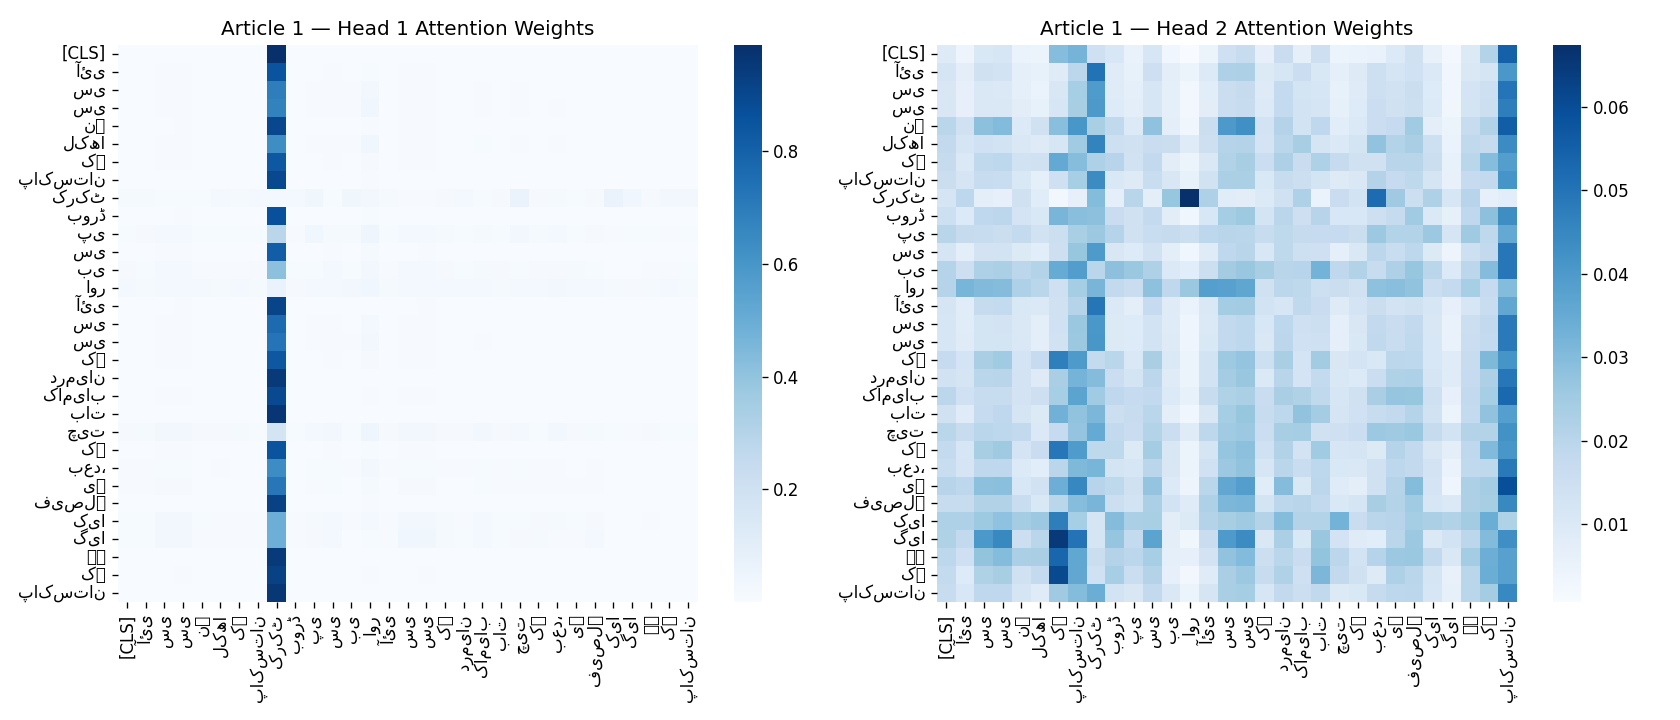

In [21]:
from Part_3.part3_evaluate import run_evaluation
run_evaluation()

from IPython.display import Image, display

# Display generated files
display(Image(filename='Part_3/models/training_curves_cls.png'))
display(Image(filename='Part_3/models/transformer_confusion_matrix.png'))
try:
    display(Image(filename='Part_3/models/attention_article_1.png'))
except: pass
